In [2]:
import pandas as pd
import numpy as np

# Load the original dataset
df = pd.read_csv("supplyChain.csv")

print("Dataset shape:", df.shape)

Dataset shape: (20000, 13)


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns:
['Timestamp', 'Supplier_ID', 'Port_Congestion', 'geopolitical_risk', 'weather_severity', 'Supplier_Reliability', 'Supplier_Capacity_Utilization', 'Inventory_Level', 'Demand_Volatility', 'Lead_Time_Days', 'Shipping_Cost_Index', 'Risk_Level', 'Risk_Score']

Data types:
Timestamp                            str
Supplier_ID                        int64
Port_Congestion                  float64
geopolitical_risk                float64
weather_severity                 float64
Supplier_Reliability             float64
Supplier_Capacity_Utilization    float64
Inventory_Level                    int64
Demand_Volatility                float64
Lead_Time_Days                     int64
Shipping_Cost_Index              float64
Risk_Level                           str
Risk_Score                       float64
dtype: object


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Timestamp                        0
Supplier_ID                      0
Port_Congestion                  0
geopolitical_risk                0
weather_severity                 0
Supplier_Reliability             0
Supplier_Capacity_Utilization    0
Inventory_Level                  0
Demand_Volatility                0
Lead_Time_Days                   0
Shipping_Cost_Index              0
Risk_Level                       0
Risk_Score                       0
dtype: int64

Duplicate rows: 0


In [5]:
print("Risk Level counts:")
print(df["Risk_Level"].value_counts())

print("\nRisk Level percentage:")
print(
    df["Risk_Level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Risk Level counts:
Risk_Level
Low       8000
Medium    7000
High      5000
Name: count, dtype: int64

Risk Level percentage:
Risk_Level
Low       40.0
Medium    35.0
High      25.0
Name: proportion, dtype: float64


In [6]:
# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Start date:", df["Timestamp"].min())
print("End date:", df["Timestamp"].max())

print("\nNumber of unique days:", df["Timestamp"].dt.date.nunique())
print("Number of unique suppliers:", df["Supplier_ID"].nunique())

Start date: 2025-01-01 00:00:00
End date: 2026-02-04 00:00:00

Number of unique days: 400
Number of unique suppliers: 50


In [7]:
daily_counts = df.groupby(df["Timestamp"].dt.date).size()

print("Records per day:")
print(daily_counts.describe())

print("\nUnique record counts per day:")
print(daily_counts.value_counts().sort_index())

Records per day:
count    400.0
mean      50.0
std        0.0
min       50.0
25%       50.0
50%       50.0
75%       50.0
max       50.0
dtype: float64

Unique record counts per day:
50    400
Name: count, dtype: int64


In [8]:
daily_risk = pd.crosstab(
    df["Timestamp"].dt.date,
    df["Risk_Level"]
)

print(daily_risk.head(10))

print("\nDaily Risk_Level averages:")
print(daily_risk.mean())

Risk_Level  High  Low  Medium
Timestamp                    
2025-01-01     0   50       0
2025-01-02     0   50       0
2025-01-03     0   50       0
2025-01-04     0   50       0
2025-01-05     0   50       0
2025-01-06     0   49       1
2025-01-07     0   49       1
2025-01-08     0   48       2
2025-01-09     0   49       1
2025-01-10     0   47       3

Daily Risk_Level averages:
Risk_Level
High      12.5
Low       20.0
Medium    17.5
dtype: float64


In [9]:
daily_risk = pd.crosstab(
    df["Timestamp"].dt.date,
    df["Risk_Level"]
)

# Show selected days across the dataset
print("First 10 days:")
display(daily_risk.head(10))

print("Middle 10 days:")
display(daily_risk.iloc[195:205])

print("Last 10 days:")
display(daily_risk.tail(10))

First 10 days:


Risk_Level,High,Low,Medium
Timestamp,,,
2025-01-01,0,50,0
2025-01-02,0,50,0
2025-01-03,0,50,0
2025-01-04,0,50,0
2025-01-05,0,50,0
2025-01-06,0,49,1
2025-01-07,0,49,1
2025-01-08,0,48,2
2025-01-09,0,49,1


Middle 10 days:


Risk_Level,High,Low,Medium
Timestamp,,,
2025-07-15,18,20,12
2025-07-16,15,14,21
2025-07-17,12,14,24
2025-07-18,14,18,18
2025-07-19,15,18,17
2025-07-20,14,16,20
2025-07-21,17,17,16
2025-07-22,15,15,20
2025-07-23,15,16,19


Last 10 days:


Risk_Level,High,Low,Medium
Timestamp,,,
2026-01-26,14,20,16
2026-01-27,15,21,14
2026-01-28,14,22,14
2026-01-29,11,21,18
2026-01-30,13,19,18
2026-01-31,11,20,19
2026-02-01,13,23,14
2026-02-02,13,19,18
2026-02-03,11,23,16


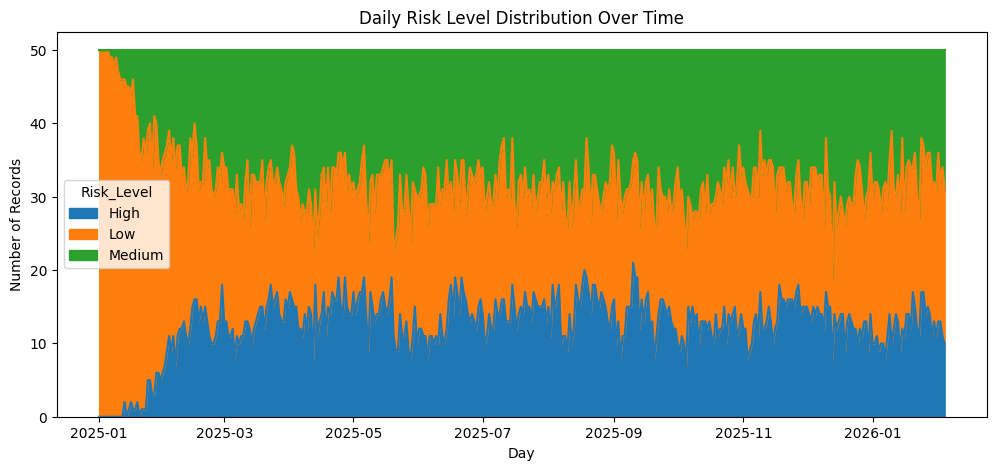

In [10]:
import matplotlib.pyplot as plt

daily_risk.plot(kind="area", stacked=True, figsize=(12, 5))

plt.title("Daily Risk Level Distribution Over Time")
plt.xlabel("Day")
plt.ylabel("Number of Records")
plt.show()

In [11]:
daily_risk["Daily_Mode"] = daily_risk.idxmax(axis=1)

print("Daily Mode distribution:")
print(daily_risk["Daily_Mode"].value_counts())

print("\nDaily Mode percentage:")
print(
    daily_risk["Daily_Mode"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Daily Mode distribution:
Daily_Mode
Low       198
Medium    169
High       33
Name: count, dtype: int64

Daily Mode percentage:
Daily_Mode
Low       49.50
Medium    42.25
High       8.25
Name: proportion, dtype: float64


In [12]:
# Calculate the percentage of each risk level for every day
daily_risk_percentage = daily_risk[["High", "Medium", "Low"]].div(
    daily_risk[["High", "Medium", "Low"]].sum(axis=1),
    axis=0
) * 100

display(daily_risk_percentage.head(10))

print("\nAverage daily percentage:")
print(daily_risk_percentage.mean().round(2))

Risk_Level,High,Medium,Low
Timestamp,,,
2025-01-01,0.0,0.0,100.0
2025-01-02,0.0,0.0,100.0
2025-01-03,0.0,0.0,100.0
2025-01-04,0.0,0.0,100.0
2025-01-05,0.0,0.0,100.0
2025-01-06,0.0,2.0,98.0
2025-01-07,0.0,2.0,98.0
2025-01-08,0.0,4.0,96.0
2025-01-09,0.0,2.0,98.0



Average daily percentage:
Risk_Level
High      25.0
Medium    35.0
Low       40.0
dtype: float64


In [13]:
print("Days containing High-risk records:")
print((daily_risk["High"] > 0).sum())

print("\nDays containing Medium-risk records:")
print((daily_risk["Medium"] > 0).sum())

print("\nDays containing Low-risk records:")
print((daily_risk["Low"] > 0).sum())

Days containing High-risk records:
386

Days containing Medium-risk records:
395

Days containing Low-risk records:
400


In [14]:
# Check records per supplier per day
supplier_daily_counts = (
    df.groupby([
        df["Timestamp"].dt.date,
        "Supplier_ID"
    ])
    .size()
)

print("Records per supplier per day:")
print(supplier_daily_counts.value_counts())

print("\nNumber of supplier-day combinations:")
print(len(supplier_daily_counts))

Records per supplier per day:
1    20000
Name: count, dtype: int64

Number of supplier-day combinations:
20000


In [15]:
# Sort the data by supplier and time
df = df.sort_values(["Supplier_ID", "Timestamp"]).reset_index(drop=True)

# Check the number of days for each supplier
supplier_days = df.groupby("Supplier_ID")["Timestamp"].nunique()

print("Days per supplier:")
print(supplier_days.value_counts())

print("\nNumber of suppliers:", df["Supplier_ID"].nunique())
print("Total records:", len(df))

Days per supplier:
Timestamp
400    50
Name: count, dtype: int64

Number of suppliers: 50
Total records: 20000


In [16]:
FEATURES = [
    "Port_Congestion",
    "geopolitical_risk",
    "weather_severity",
    "Supplier_Reliability",
    "Supplier_Capacity_Utilization",
    "Inventory_Level",
    "Demand_Volatility",
    "Lead_Time_Days",
    "Shipping_Cost_Index"
]

TARGET = "Risk_Level"

print("Number of features:", len(FEATURES))
print("Features:", FEATURES)
print("Target:", TARGET)

Number of features: 9
Features: ['Port_Congestion', 'geopolitical_risk', 'weather_severity', 'Supplier_Reliability', 'Supplier_Capacity_Utilization', 'Inventory_Level', 'Demand_Volatility', 'Lead_Time_Days', 'Shipping_Cost_Index']
Target: Risk_Level


In [17]:
WINDOW_SIZE = 7

X_windows = []
y_windows = []
prediction_dates = []
supplier_ids = []

for supplier_id, supplier_df in df.groupby("Supplier_ID"):
    supplier_df = supplier_df.sort_values("Timestamp").reset_index(drop=True)

    for i in range(WINDOW_SIZE, len(supplier_df)):
        # Previous 7 days
        window = supplier_df.iloc[i-WINDOW_SIZE:i]

        # Next day target
        target_row = supplier_df.iloc[i]

        X_windows.append(window[FEATURES].values.flatten())
        y_windows.append(target_row[TARGET])
        prediction_dates.append(target_row["Timestamp"])
        supplier_ids.append(supplier_id)

X_windows = np.array(X_windows)
y_windows = np.array(y_windows)
prediction_dates = np.array(prediction_dates)
supplier_ids = np.array(supplier_ids)

print("X shape:", X_windows.shape)
print("y shape:", y_windows.shape)
print("Number of windows:", len(X_windows))

X shape: (19650, 63)
y shape: (19650,)
Number of windows: 19650


In [18]:
target_distribution = pd.Series(y_windows).value_counts()

print(target_distribution)
print("\nPercentages:")
print((target_distribution / len(y_windows) * 100).round(2))

Low       7652
Medium    6998
High      5000
Name: count, dtype: int64

Percentages:
Low       38.94
Medium    35.61
High      25.45
Name: count, dtype: float64


In [19]:
unique_prediction_dates = np.sort(np.unique(prediction_dates))

print("First prediction date:", unique_prediction_dates[0])
print("Last prediction date:", unique_prediction_dates[-1])
print("Number of prediction dates:", len(unique_prediction_dates))

First prediction date: 2025-01-08 00:00:00
Last prediction date: 2026-02-04 00:00:00
Number of prediction dates: 393


In [20]:
n_dates = len(unique_prediction_dates)

train_end = int(n_dates * 0.60)
val_end = int(n_dates * 0.80)

train_dates = unique_prediction_dates[:train_end]
val_dates = unique_prediction_dates[train_end:val_end]
test_dates = unique_prediction_dates[val_end:]

train_mask = np.isin(prediction_dates, train_dates)
val_mask = np.isin(prediction_dates, val_dates)
test_mask = np.isin(prediction_dates, test_dates)

X_train = X_windows[train_mask]
y_train = y_windows[train_mask]

X_val = X_windows[val_mask]
y_val = y_windows[val_mask]

X_test = X_windows[test_mask]
y_test = y_windows[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (11750, 63) (11750,)
Validation: (3950, 63) (3950,)
Test: (3950, 63) (3950,)


In [21]:
print("Train dates:", train_dates[0], "→", train_dates[-1])
print("Validation dates:", val_dates[0], "→", val_dates[-1])
print("Test dates:", test_dates[0], "→", test_dates[-1])

Train dates: 2025-01-08 00:00:00 → 2025-08-30 00:00:00
Validation dates: 2025-08-31 00:00:00 → 2025-11-17 00:00:00
Test dates: 2025-11-18 00:00:00 → 2026-02-04 00:00:00


In [22]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
model_dt = DecisionTreeClassifier(
    random_state=42
)

# Train the model
model_dt.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [23]:
y_val_pred = model_dt.predict(X_val)
y_test_pred = model_dt.predict(X_test)

print("Validation predictions:", len(y_val_pred))
print("Test predictions:", len(y_test_pred))

Validation predictions: 3950
Test predictions: 3950


In [24]:
from sklearn.metrics import accuracy_score

val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Validation Accuracy: 0.5985
Test Accuracy: 0.6023


In [25]:
from sklearn.metrics import classification_report

print("Validation Report:")
print(classification_report(y_val, y_val_pred))

print("\nTest Report:")
print(classification_report(y_test, y_test_pred))

Validation Report:
              precision    recall  f1-score   support

        High       0.64      0.63      0.64      1018
         Low       0.66      0.64      0.65      1444
      Medium       0.51      0.53      0.52      1488

    accuracy                           0.60      3950
   macro avg       0.61      0.60      0.60      3950
weighted avg       0.60      0.60      0.60      3950


Test Report:
              precision    recall  f1-score   support

        High       0.66      0.67      0.67      1038
         Low       0.67      0.65      0.66      1469
      Medium       0.50      0.50      0.50      1443

    accuracy                           0.60      3950
   macro avg       0.61      0.61      0.61      3950
weighted avg       0.60      0.60      0.60      3950



In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["High", "Medium", "Low"]
)

print("Test Confusion Matrix:")
print(pd.DataFrame(
    cm,
    index=["Actual High", "Actual Medium", "Actual Low"],
    columns=["Pred High", "Pred Medium", "Pred Low"]
))

Test Confusion Matrix:
               Pred High  Pred Medium  Pred Low
Actual High          695          284        59
Actual Medium        295          723       425
Actual Low            61          447       961


In [27]:
print("Actual test distribution:")
print(pd.Series(y_test).value_counts())

print("\nPredicted test distribution:")
print(pd.Series(y_test_pred).value_counts())

Actual test distribution:
Low       1469
Medium    1443
High      1038
Name: count, dtype: int64

Predicted test distribution:
Medium    1454
Low       1445
High      1051
Name: count, dtype: int64


In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [3, 5, 7, 10, 15, 20, None]

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    val_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, val_pred)
    
    print(f"max_depth={depth}: Validation Accuracy = {accuracy:.4f}")

max_depth=3: Validation Accuracy = 0.6438
max_depth=5: Validation Accuracy = 0.6651
max_depth=7: Validation Accuracy = 0.6732
max_depth=10: Validation Accuracy = 0.6375
max_depth=15: Validation Accuracy = 0.6084
max_depth=20: Validation Accuracy = 0.5990
max_depth=None: Validation Accuracy = 0.5985


In [29]:
final_model_dt = DecisionTreeClassifier(
    max_depth=7,
    random_state=42
)

final_model_dt.fit(X_train, y_train)

# Predictions
final_val_pred = final_model_dt.predict(X_val)
final_test_pred = final_model_dt.predict(X_test)

print("Final Decision Tree trained.")

Final Decision Tree trained.


In [30]:
from sklearn.metrics import accuracy_score, classification_report

final_val_accuracy = accuracy_score(y_val, final_val_pred)
final_test_accuracy = accuracy_score(y_test, final_test_pred)

print(f"Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Test Accuracy: {final_test_accuracy:.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, final_test_pred))

Validation Accuracy: 0.6732
Test Accuracy: 0.6775

Test Classification Report:
              precision    recall  f1-score   support

        High       0.77      0.68      0.73      1038
         Low       0.74      0.74      0.74      1469
      Medium       0.56      0.61      0.58      1443

    accuracy                           0.68      3950
   macro avg       0.69      0.68      0.68      3950
weighted avg       0.68      0.68      0.68      3950



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    final_test_pred,
    labels=["High", "Medium", "Low"]
)

print(pd.DataFrame(
    cm,
    index=["Actual High", "Actual Medium", "Actual Low"],
    columns=["Pred High", "Pred Medium", "Pred Low"]
))

               Pred High  Pred Medium  Pred Low
Actual High          711          301        26
Actual Medium        203          876       364
Actual Low             5          375      1089


In [32]:
from sklearn.metrics import roc_auc_score

y_test_proba = final_model_dt.predict_proba(X_test)

macro_auc = roc_auc_score(
    y_test,
    y_test_proba,
    multi_class="ovr",
    average="macro",
    labels=final_model_dt.classes_
)

print(f"Macro AUC: {macro_auc:.4f}")

Macro AUC: 0.8354


In [33]:
from sklearn.metrics import f1_score

# Predictions on training and validation data
train_pred = final_model_dt.predict(X_train)
val_pred = final_model_dt.predict(X_val)

# Macro F1
train_f1 = f1_score(y_train, train_pred, average="macro")
val_f1 = f1_score(y_val, val_pred, average="macro")

# Train–Validation Gap
train_val_gap = train_f1 - val_f1

print(f"Train F1: {train_f1:.4f}")
print(f"Validation F1: {val_f1:.4f}")
print(f"Train–Val Gap: {train_val_gap:.4f}")

Train F1: 0.7479
Validation F1: 0.6771
Train–Val Gap: 0.0708


In [34]:
importances = final_model_dt.feature_importances_

# Create names for the 63 window features
window_feature_names = []

for day in range(1, WINDOW_SIZE + 1):
    for feature in FEATURES:
        window_feature_names.append(f"{feature}_Day_{day}")

feature_importance_df = pd.DataFrame({
    "Feature": window_feature_names,
    "Importance": importances
})

# Extract the original feature name
feature_importance_df["Base_Feature"] = (
    feature_importance_df["Feature"]
    .str.replace(r"_Day_\d+$", "", regex=True)
)

# Sum importance across the 7 days
grouped_importance = (
    feature_importance_df
    .groupby("Base_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print(grouped_importance)

Base_Feature
geopolitical_risk                0.486581
Port_Congestion                  0.280160
weather_severity                 0.090191
Supplier_Reliability             0.067680
Demand_Volatility                0.055373
Supplier_Capacity_Utilization    0.006571
Shipping_Cost_Index              0.006051
Inventory_Level                  0.005996
Lead_Time_Days                   0.001396
Name: Importance, dtype: float64


In [35]:
feature_importance_final = (
    grouped_importance
    .reset_index()
    .rename(columns={
        "Base_Feature": "Feature",
        "Importance": "Importance"
    })
)

feature_importance_final["Importance"] = (
    feature_importance_final["Importance"].round(4)
)

print(feature_importance_final)

                         Feature  Importance
0              geopolitical_risk      0.4866
1                Port_Congestion      0.2802
2               weather_severity      0.0902
3           Supplier_Reliability      0.0677
4              Demand_Volatility      0.0554
5  Supplier_Capacity_Utilization      0.0066
6            Shipping_Cost_Index      0.0061
7                Inventory_Level      0.0060
8                 Lead_Time_Days      0.0014


In [36]:
import joblib

joblib.dump(
    final_model_dt,
    "../models/decision_tree_7day.pkl"
)

print("Decision Tree model saved successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '../models/decision_tree_7day.pkl'

In [ ]:
metrics = {
    "Validation Accuracy": 0.6732,
    "Test Accuracy": 0.6775,
    "Macro F1": 0.68,
    "Macro AUC": 0.8354
}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    "../models/decision_tree_metrics.csv",
    index=False
)

print("Metrics saved successfully.")

Metrics saved successfully.


In [ ]:
feature_importance_df.to_csv(
    "../models/decision_tree_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


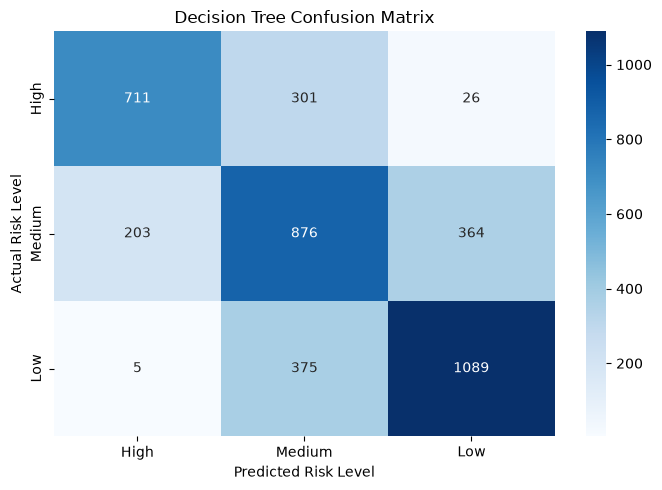

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    final_test_pred,
    labels=["High", "Medium", "Low"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Medium", "Low"],
    yticklabels=["High", "Medium", "Low"]
)

plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Risk Level")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

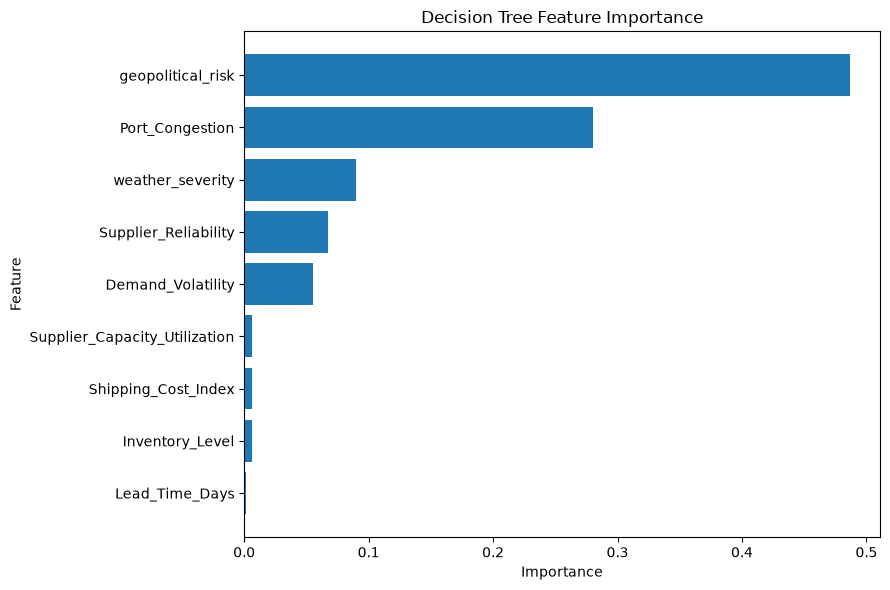

In [ ]:
import matplotlib.pyplot as plt

importance_plot = grouped_importance.sort_values(ascending=True)

plt.figure(figsize=(9, 6))

plt.barh(
    importance_plot.index,
    importance_plot.values
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()